# Tracking → pool coordinates → top-down video

This notebook reads `tracking_data-3.csv`, maps camera pixels to **meters on the water surface**, and makes a video with one dot per player and one for the ball.

Run the cells from top to bottom. The playing area is **25 × 20 meters**, as confirmed. The reference is the **right-side goal in the camera view**.

A *homography* is a perspective transformation between two planes. Four known, non-collinear point pairs are enough; additional measured points let us check the fit. This assumes a fixed camera and tracking coordinates in the same image coordinate system throughout the clip. Dots are approximate: a swimmer's head, a ball in the air, or the center of a cone is above the water plane. For best accuracy, calibrate using each cone's base at water level.

## 1. Install and import
Run the install cell once in the notebook's Python environment. No GPU is needed.

In [1]:
%pip install -q numpy pandas matplotlib opencv-python-headless imageio imageio-ffmpeg

Dependencies already available; installation skipped.


In [2]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import cv2
import imageio.v2 as imageio
from IPython.display import display, Video

# Works when the notebook is started from notebooks/ or the repository root.
CSV_PATH = Path("tracking_data-3.csv")
if not CSV_PATH.exists():
    CSV_PATH = Path("notebooks/tracking_data-3.csv")
OUTPUT_DIR = CSV_PATH.parent / "pool_tracking_output"
OUTPUT_DIR.mkdir(exist_ok=True)

## 2. Read the tracking data
Use **the number in `label`**, not `object_id`: in this file, “Object 2” has numeric ID 1.

Object 2 is the ball; objects 3–8 are players; objects 9–14 are calibration cones. Object 15 is ignored because its role was not specified. Missing player detections will simply be absent from those video frames.

In [3]:
df = pd.read_csv(CSV_PATH)
required = {"frame_index", "timestamp", "label", "x_pixel", "y_pixel"}
assert required <= set(df.columns), f"Missing columns: {required - set(df.columns)}"
df["object_number"] = pd.to_numeric(df["label"].str.extract(r"Object\s+(\d+)", expand=False))
assert df["object_number"].notna().all(), "Unexpected object label."
assert not df.duplicated(["frame_index", "object_number"]).any(), "Duplicate object/frame rows."
assert np.isfinite(df[["frame_index", "timestamp", "x_pixel", "y_pixel"]].to_numpy()).all()
assert (df.frame_index >= 0).all() and (df.frame_index % 1 == 0).all()
df["frame_index"] = df["frame_index"].astype(int)
display(df.groupby("object_number").agg(label=("label", "first"), detections=("label", "size")))

# Timestamp units are not declared by the CSV. Microseconds imply about 24 FPS.
# Change this value if you know the export uses a different unit.
TIMESTAMP_UNITS_PER_SECOND = 1_000_000
FPS_OVERRIDE = None  # Set to the source FPS if known, e.g. 24.0.
assert df.groupby("frame_index")["timestamp"].nunique().max() == 1
frame_times = df.groupby("frame_index")["timestamp"].first().sort_index()
dt = np.diff(frame_times.to_numpy()) / TIMESTAMP_UNITS_PER_SECOND
dframes = np.diff(frame_times.index.to_numpy())
assert len(dt) > 0 and (dt > 0).all(), "Need increasing frame timestamps."
FPS = float(FPS_OVERRIDE) if FPS_OVERRIDE is not None else float(np.median(dframes / dt))
assert np.isfinite(FPS) and FPS > 0
print(f"Video frame rate: {FPS:.3f} FPS")
if not np.allclose(dt / dframes, 1 / FPS, rtol=0.02):
    print("Timing is irregular or overridden; the output uses a constant frame rate.")

,label,detections
object_number,,
2,Object 2,240
3,Object 3,240
4,Object 4,233
5,Object 5,240
6,Object 6,240
7,Object 7,235
8,Object 8,227
9,Object 9,240
10,Object 10,240


Video frame rate: 24.000 FPS


## 3. Describe the real pool (edit this cell)
We define **x = distance from the goal line into the pitch**, and **y = distance from the far sideline toward the near sideline**, in meters. On the final drawing, the reference goal is on the right: x increases leftward into the pitch, and y increases downward. “Far/top” and “near/bottom” mean the sides in your camera view.

The starting mapping below interprets your descriptions as:
- 9: far sideline, 6 m from the goal line.
- 10: far sideline, 2 m from the **same** goal line.
- 13: near sideline, 2 m from that goal line.
- 14: near sideline, **5 m**, as you specified.

These four cones can define the homography, provided they really mark those water-plane locations. Change their coordinates if necessary. Cones 11 and 12 are also included: both lie on the right goal line (x = 0), 2 m outward from their nearest goal posts. With a centered 3 m goal, their coordinates are (0, 6.5) and (0, 13.5). The fit uses all six cones; their residual errors show how consistently the tracked points match the measured geometry. The goal is 3 m wide and is drawn centered on the goal line (y = 8.5 to 11.5 m); edit GOAL_CENTER_Y_M if it is offset.

Set the length and width of the playing area, measured between its goal lines and sidelines. If cones sit outside those lines, use their actual measured coordinates, even if y is negative or larger than the width.

In [4]:
POOL_LENGTH_M = 25.0  # Playing length, confirmed in meters.
POOL_WIDTH_M = 20.0   # Playing width, confirmed in meters.
GOAL_WIDTH_M = 3.0
GOAL_CENTER_Y_M = POOL_WIDTH_M / 2  # Assume the goal is centered across the width.

if POOL_LENGTH_M is None or POOL_WIDTH_M is None:
    raise ValueError("Enter POOL_LENGTH_M and POOL_WIDTH_M above, then rerun this cell.")
assert POOL_LENGTH_M > 0 and POOL_WIDTH_M > 0

CONE_WORLD_M = {
    9: (6.0, 0.0),
    10: (2.0, 0.0),
    11: (0.0, GOAL_CENTER_Y_M - GOAL_WIDTH_M / 2 - 2.0),  # 2 m outside far goal post.
    12: (0.0, GOAL_CENTER_Y_M + GOAL_WIDTH_M / 2 + 2.0),  # 2 m outside near goal post.
    13: (2.0, POOL_WIDTH_M),
    14: (5.0, POOL_WIDTH_M),
}

# Optional: replace a tracked cone center with a manually picked base point.
# Pixel coordinates must use the SAME image size as this CSV.
CONE_PIXEL_OVERRIDES = {}  # Example syntax: {9: (pixel_x, pixel_y)}

## 4. Locate the cones in the camera view
Take the median tracked position of each fixed cone to reduce tracking jitter. Inspect the plot: the cone labels should agree with your camera view. Large motion of a fixed cone can indicate tracking errors or camera movement; one constant homography cannot correct a moving camera.

,x_std_pixels,y_std_pixels
object_number,,
9,12.023680,17.808723
10,11.416991,15.573664
11,10.799042,13.007890
12,10.550853,10.903403
13,10.560735,10.111107
14,10.617484,10.006596


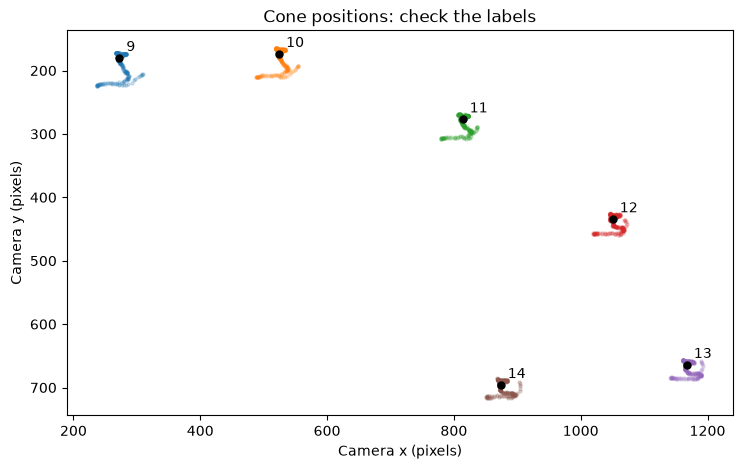

In [5]:
cone_rows = df[df.object_number.between(9, 14)]
cone_pixels = cone_rows.groupby("object_number")[["x_pixel", "y_pixel"]].median()
for number, xy in CONE_PIXEL_OVERRIDES.items():
    cone_pixels.loc[number] = xy
spread = cone_rows.groupby("object_number")[["x_pixel", "y_pixel"]].std()
display(spread.rename(columns={"x_pixel": "x_std_pixels", "y_pixel": "y_std_pixels"}))
fig, ax = plt.subplots(figsize=(10, 5))
for number, rows in cone_rows.groupby("object_number"):
    ax.scatter(rows.x_pixel, rows.y_pixel, s=5, alpha=0.2)
    x, y = cone_pixels.loc[number]
    ax.scatter(x, y, c="black", s=25)
    ax.annotate(str(number), (x, y), xytext=(5, 5), textcoords="offset points")
ax.invert_yaxis()
ax.set_aspect("equal")
ax.set(xlabel="Camera x (pixels)", ylabel="Camera y (pixels)", title="Cone positions: check the labels")
plt.show()

## 5. Fit the homography
Each calibration pair connects one camera point `(x_pixel, y_pixel)` to its known pool position `(x_m, y_m)`. OpenCV finds the 3×3 matrix H that maps between them.

With four points, a tiny fitting error is expected and **does not prove the coordinates are correct**. An additional measured cone is a useful independent check. With more than four points we fit all supplied points and report their residuals. Accuracy generally gets worse far from the calibration cones.

In [6]:
cone_ids = [k for k, xy in CONE_WORLD_M.items() if xy is not None]
assert len(cone_ids) >= 4, "Need at least four measured cones."
assert set(cone_ids) <= set(cone_pixels.index), "A calibration cone is missing from the CSV."
source = cone_pixels.loc[cone_ids].to_numpy(dtype=np.float64)
target = np.array([CONE_WORLD_M[k] for k in cone_ids], dtype=np.float64)
assert np.isfinite(source).all() and np.isfinite(target).all()
for points in (source, target):
    assert np.linalg.matrix_rank(points - points.mean(axis=0)) == 2, "Cones cannot all lie on one line."
H, _ = cv2.findHomography(source, target, method=0)
assert H is not None and np.isfinite(H).all() and np.linalg.matrix_rank(H) == 3, "Calibration is degenerate."

def pixels_to_pool(points):
    """Apply H, dividing by the third homogeneous coordinate."""
    points = np.asarray(points, dtype=float)
    homogeneous = np.column_stack([points, np.ones(len(points))]) @ H.T
    result = np.full((len(points), 2), np.nan)
    valid = np.abs(homogeneous[:, 2]) > 1e-9
    result[valid] = homogeneous[valid, :2] / homogeneous[valid, 2, None]
    return result

fitted = pixels_to_pool(source)
calibration = pd.DataFrame({"cone": cone_ids, "known_x_m": target[:, 0],
    "known_y_m": target[:, 1], "mapped_x_m": fitted[:, 0], "mapped_y_m": fitted[:, 1],
    "fit_error_m": np.linalg.norm(fitted - target, axis=1)})
display(calibration.round(3))
calibration.to_csv(OUTPUT_DIR / "calibration_errors.csv", index=False)
CALIBRATION_NEEDS_REVIEW = calibration.fit_error_m.max() > 0.5
if CALIBRATION_NEEDS_REVIEW:
    print("Calibration needs review: cone fit errors exceed 0.5 m. Treat output as approximate.")
np.save(OUTPUT_DIR / "homography.npy", H)

,cone,known_x_m,known_y_m,mapped_x_m,mapped_y_m,fit_error_m
0,9,6.0,0.0,5.963,-0.010,0.039
1,10,2.0,0.0,2.076,0.003,0.076
2,11,0.0,6.5,-0.033,6.504,0.033
3,12,0.0,13.5,-0.049,13.511,0.050
4,13,2.0,20.0,2.054,19.968,0.063
5,14,5.0,20.0,4.991,20.024,0.025


## 6. Convert ball and player positions
Save the original pixel coordinates alongside the new meter coordinates. Keep out-of-pool points in the CSV and flag them rather than pushing them artificially onto a boundary. They can reveal a bad calibration, points above the water, or tracking errors.

0 / 1655 detections map outside the playing area.


,frame_index,timestamp,object_id,label,x_pixel,y_pixel,object_number,x_m,y_m,inside_pool
0,0,83333,1,Object 2,411.0,241.5,2,4.872612,3.854940,True
1,1,125000,1,Object 2,411.5,242.5,2,4.880077,3.910084,True
2,2,166666,1,Object 2,412.0,243.5,2,4.887523,3.965084,True
3,3,208333,1,Object 2,411.0,244.0,2,4.908204,3.990154,True
4,4,250000,1,Object 2,410.0,245.5,2,4.942985,4.068943,True


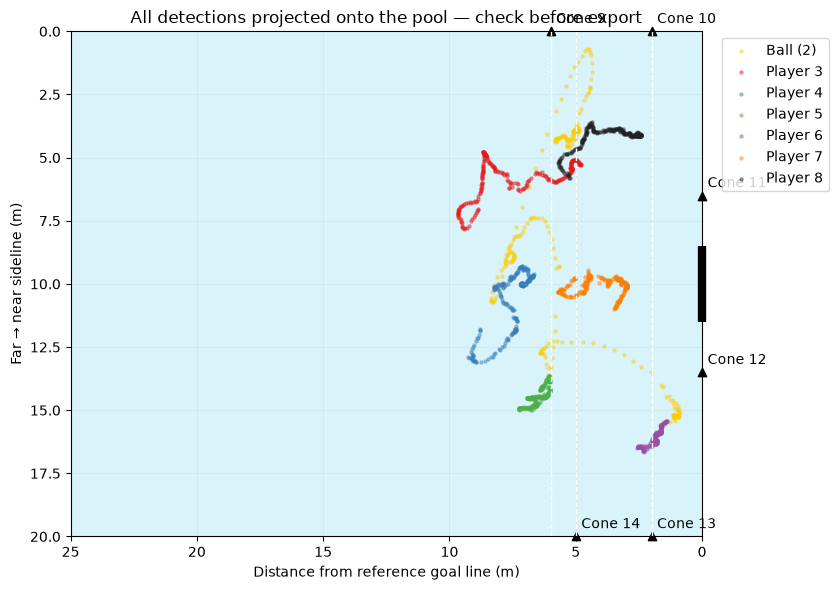

In [7]:
tracks = df[df.object_number.between(2, 8)].copy()
tracks[["x_m", "y_m"]] = pixels_to_pool(tracks[["x_pixel", "y_pixel"]].to_numpy())
tracks["inside_pool"] = tracks.x_m.between(0, POOL_LENGTH_M) & tracks.y_m.between(0, POOL_WIDTH_M)
tracks.to_csv(OUTPUT_DIR / "tracking_pool_meters.csv", index=False)
print(f"{(~tracks.inside_pool).sum()} / {len(tracks)} detections map outside the playing area.")
display(tracks.head())

# Shared drawing code keeps the preview and video consistent.
COLORS = {2: "#ffcc00", 3: "#e41a1c", 4: "#377eb8", 5: "#4daf4a",
          6: "#984ea3", 7: "#ff7f00", 8: "#222222"}
def draw_pool(ax):
    ax.set_facecolor("#d9f3fa")
    # A thick segment marks the 3 m goal mouth, centered on the right goal line.
    ax.plot([0, 0], [GOAL_CENTER_Y_M - GOAL_WIDTH_M / 2,
                     GOAL_CENTER_Y_M + GOAL_WIDTH_M / 2],
            color="black", lw=6, solid_capstyle="butt", clip_on=False)
    ax.set_xlim(POOL_LENGTH_M, 0)  # Reference goal appears on the right, like the camera view.
    ax.set_ylim(POOL_WIDTH_M, 0)
    ax.set_aspect("equal")
    ax.set(xlabel="Distance from reference goal line (m)", ylabel="Far → near sideline (m)")
    for distance in (2, 5, 6):
        if distance < POOL_LENGTH_M:
            ax.axvline(distance, color="white", lw=1, linestyle="--")
    ax.grid(alpha=0.15)

fig, ax = plt.subplots(figsize=(10, 6))
draw_pool(ax)
for number, rows in tracks.groupby("object_number"):
    ax.scatter(rows.x_m, rows.y_m, s=5, color=COLORS[number], alpha=0.4,
               label="Ball (2)" if number == 2 else f"Player {number}")
ax.scatter(target[:, 0], target[:, 1], marker="^", color="black", clip_on=False)
for number, xy in zip(cone_ids, target):
    ax.annotate(f"Cone {number}", xy, xytext=(4, 6), textcoords="offset points")
ax.legend(loc="upper left", bbox_to_anchor=(1.02, 1))
ax.set_title("All detections projected onto the pool — check before export")
plt.tight_layout()
plt.show()

## 7. Render a top-down MP4
Draw each frame at the CSV's frame rate. The yellow dot is the ball; the other dots are players, labeled with their object numbers. Missing detections are not interpolated. Points outside the playing area are omitted from the video, but remain in the exported CSV. The title reports how many dots are visible.

The output is H.264 MP4 for playback in VS Code or a browser. Its timing is relative to the first tracked frame, not the start of the original source video.

In [8]:
VIDEO_PATH = OUTPUT_DIR / "pool_topdown.mp4"
first_frame = int(df.frame_index.min())
last_frame = int(df.frame_index.max())
by_frame = {int(frame): rows for frame, rows in tracks.groupby("frame_index")}

fig, ax = plt.subplots(figsize=(10, 6), dpi=100)
draw_pool(ax)
fig.subplots_adjust(left=0.10, right=0.82, bottom=0.13, top=0.88)
dots, labels = {}, {}
for number in range(2, 9):
    name = "Ball (2)" if number == 2 else f"Player {number}"
    dots[number] = ax.scatter([], [], s=75 if number == 2 else 110,
                              color=COLORS[number], edgecolors="white", label=name)
    labels[number] = ax.annotate(str(number), (0, 0), xytext=(6, 6), textcoords="offset points")
ax.legend(loc="upper left", bbox_to_anchor=(1.02, 1))

try:
    with imageio.get_writer(str(VIDEO_PATH), fps=FPS, codec="libx264",
                            quality=8, macro_block_size=2) as writer:
        for frame in range(first_frame, last_frame + 1):
            # Clear the previous frame, so missing tracks do not leave stale dots.
            for number in dots:
                dots[number].set_offsets(np.empty((0, 2)))
                labels[number].set_visible(False)
            rows = by_frame.get(frame, tracks.iloc[:0])
            visible = rows[rows.inside_pool]
            for row in visible.itertuples():
                number = int(row.object_number)
                dots[number].set_offsets([[row.x_m, row.y_m]])
                labels[number].xy = (row.x_m, row.y_m)
                labels[number].set_visible(True)
            seconds = (frame - first_frame) / FPS
            status = "Approximate calibration | " if CALIBRATION_NEEDS_REVIEW else ""
            ax.set_title(f"{status}{seconds:.2f} s | frame {frame} | {len(visible)} dots")
            fig.canvas.draw()
            rgb = np.asarray(fig.canvas.buffer_rgba())[:, :, :3].copy()
            writer.append_data(rgb)
finally:
    plt.close(fig)

print(f"Saved: {VIDEO_PATH.resolve()}")
print(f"Frames: {last_frame - first_frame + 1}; duration: {(last_frame - first_frame + 1) / FPS:.2f} s")
Video(str(VIDEO_PATH), embed=True)

Saved: /workspace/sam2/notebooks/pool_tracking_output/pool_topdown.mp4
Frames: 240; duration: 10.00 s


## Output files
Check the calibration error table before treating this as a precise measurement. Tracked cone centers, incorrect cone distances, and camera motion can affect accuracy. The video is labeled approximate when fitting errors exceed 0.5 m; this threshold is a review prompt, not an accuracy guarantee.

`pool_tracking_output/` contains:
- `calibration_errors.csv`: residual error for each calibration cone.
- `tracking_pool_meters.csv`: ball/player detections with meter coordinates and an inside-pool flag.
- `homography.npy`: the calibration matrix.
- `pool_topdown.mp4`: the animated top-down view.

If the preview looks wrong, first check the cone labels, real-world coordinates, and whether the camera moved. Do not interpret these positions as accurate measurements until the calibration is checked against additional known locations.